<a href="https://colab.research.google.com/github/Abi-ijlan/Panda_study/blob/main/base_line.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np

# ── Segment split ─────────────────────────────────────────────────────────────
total_segments  = 2522
#typical_ratio   = 0.75
#pier_ej_ratio   = 0.25

typical_segments = 2000   # ~1892
pier_ej_segments = 522   # ~630

# ── Cycle times ───────────────────────────────────────────────────────────────
typical_cycle_hrs = 40
pier_ej_cycle_hrs = 68

# ── Shift basis ───────────────────────────────────────────────────────────────
shift_hrs_per_day = 20

# ── Mould ramp-up ─────────────────────────────────────────────────────────────
moulds_per_batch  = 3       # moulds added every ramp-up period
ramp_up_months    = 1.5     # months between each batch
total_moulds      = 13
typical_moulds    = 10      # first to come online
pier_moulds       = 3       # come online after all typical moulds

print(f"Typical segments : {typical_segments}")
print(f"Pier/EJ segments : {pier_ej_segments}")
print(f"Total            : {typical_segments + pier_ej_segments}")

Typical segments : 2000
Pier/EJ segments : 522
Total            : 2522


In [22]:
# ── Days per month ────────────────────────────────────────────────────────────
days_per_month = 30

# ── Available hours per mould per month ──────────────────────────────────────
hours_per_month = days_per_month * shift_hrs_per_day   # 30 × 20 = 600 hrs

# ── Segments per mould per month ─────────────────────────────────────────────
typical_per_mould_month = hours_per_month / typical_cycle_hrs   # 600 / 40 = 15
pier_per_mould_month    = hours_per_month / pier_ej_cycle_hrs   # 600 / 68 ≈ 8.8

print(f"Hours available per mould per month : {hours_per_month} hrs")
print(f"Typical segments per mould/month    : {typical_per_mould_month:.1f}")
print(f"Pier/EJ segments per mould/month    : {pier_per_mould_month:.1f}")

Hours available per mould per month : 600 hrs
Typical segments per mould/month    : 15.0
Pier/EJ segments per mould/month    : 8.8


In [23]:
# ── Ramp-up schedule ─────────────────────────────────────────────────────────
# Typical moulds come online first (3 every 1.5 months)
# After all typical moulds, pier moulds come online

ramp_schedule = []

active_typical = 0
active_pier    = 0
month          = 0

# Add typical moulds first
while active_typical < typical_moulds:
    active_typical = min(active_typical + moulds_per_batch, typical_moulds)
    ramp_schedule.append({
        'Month'          : month,
        'Active_Typical' : active_typical,
        'Active_Pier'    : active_pier
    })
    month += ramp_up_months

# Then add pier moulds
while active_pier < pier_moulds:
    active_pier = min(active_pier + moulds_per_batch, pier_moulds)
    ramp_schedule.append({
        'Month'          : month,
        'Active_Typical' : active_typical,
        'Active_Pier'    : active_pier
    })
    month += ramp_up_months

df_ramp = pd.DataFrame(ramp_schedule)
print(df_ramp)

   Month  Active_Typical  Active_Pier
0    0.0               3            0
1    1.5               6            0
2    3.0               9            0
3    4.5              10            0
4    6.0              10            3


In [24]:
# ── Generate month-by-month production ───────────────────────────────────────
timeline = []

cumulative_typical = 0
cumulative_pier    = 0
month_num          = 0

while cumulative_typical < typical_segments or cumulative_pier < pier_ej_segments:

    # Find active moulds for this month based on ramp-up schedule
    ramp_now = df_ramp[df_ramp['Month'] <= month_num].iloc[-1]
    active_typical_now = ramp_now['Active_Typical']
    active_pier_now    = ramp_now['Active_Pier']

    # Raw output this month
    typical_output = active_typical_now * typical_per_mould_month
    pier_output    = active_pier_now    * pier_per_mould_month

    # Cap at remaining segments
    typical_output = min(typical_output, typical_segments - cumulative_typical)
    pier_output    = min(pier_output,    pier_ej_segments - cumulative_pier)

    cumulative_typical += typical_output
    cumulative_pier    += pier_output

    timeline.append({
        'Month'              : month_num + 1,
        'Active_Typical'     : int(active_typical_now),
        'Active_Pier'        : int(active_pier_now),
        'Typical_Output'     : round(typical_output, 1),
        'Pier_Output'        : round(pier_output, 1),
        'Total_Output'       : round(typical_output + pier_output, 1),
        'Cumulative_Typical' : round(cumulative_typical, 1),
        'Cumulative_Pier'    : round(cumulative_pier, 1),
        'Cumulative_Total'   : round(cumulative_typical + cumulative_pier, 1)
    })

    month_num += 1

df_timeline = pd.DataFrame(timeline)
print(df_timeline.to_string(index=False))
print(f"\nProject completes in {month_num} months")

 Month  Active_Typical  Active_Pier  Typical_Output  Pier_Output  Total_Output  Cumulative_Typical  Cumulative_Pier  Cumulative_Total
     1               3            0            45.0          0.0          45.0                45.0              0.0              45.0
     2               3            0            45.0          0.0          45.0                90.0              0.0              90.0
     3               6            0            90.0          0.0          90.0               180.0              0.0             180.0
     4               9            0           135.0          0.0         135.0               315.0              0.0             315.0
     5               9            0           135.0          0.0         135.0               450.0              0.0             450.0
     6              10            0           150.0          0.0         150.0               600.0              0.0             600.0
     7              10            3           150.0         26

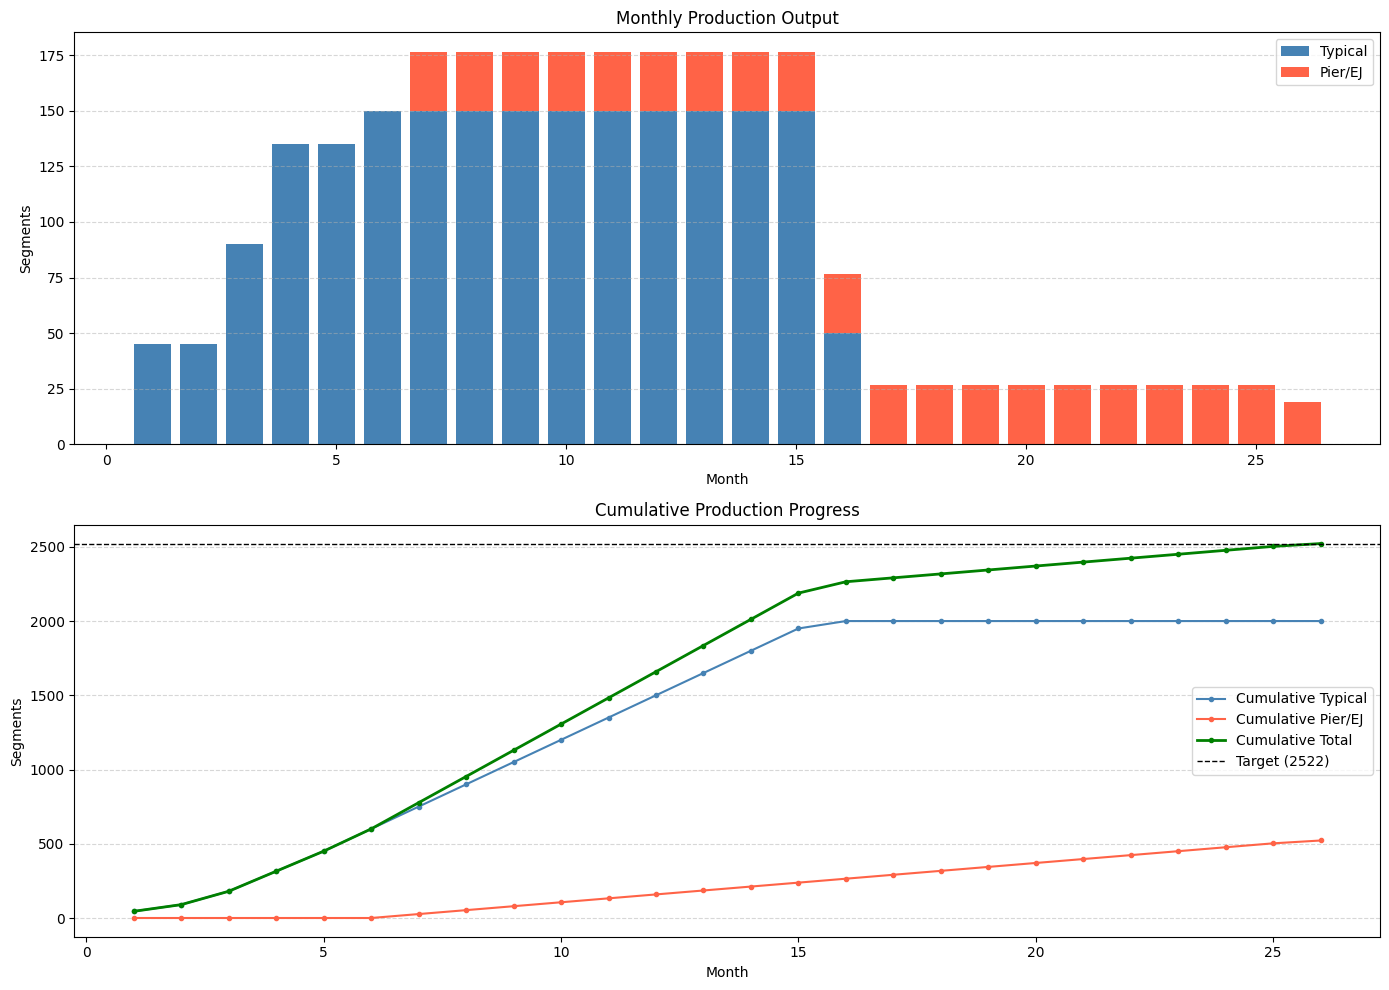


Base plan completes in 26 months


In [25]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ── Chart 1: Monthly Production (stacked bar) ─────────────────────────────────
ax1.bar(df_timeline['Month'], df_timeline['Typical_Output'],
        label='Typical', color='steelblue')
ax1.bar(df_timeline['Month'], df_timeline['Pier_Output'],
        bottom=df_timeline['Typical_Output'],
        label='Pier/EJ', color='tomato')

ax1.set_xlabel('Month')
ax1.set_ylabel('Segments')
ax1.set_title('Monthly Production Output')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# ── Chart 2: Cumulative Production (line) ─────────────────────────────────────
ax2.plot(df_timeline['Month'], df_timeline['Cumulative_Typical'],
         label='Cumulative Typical', color='steelblue', marker='o', markersize=3)
ax2.plot(df_timeline['Month'], df_timeline['Cumulative_Pier'],
         label='Cumulative Pier/EJ', color='tomato', marker='o', markersize=3)
ax2.plot(df_timeline['Month'], df_timeline['Cumulative_Total'],
         label='Cumulative Total', color='green', linewidth=2, marker='o', markersize=3)

# Target line
ax2.axhline(y=total_segments, color='black', linestyle='--', linewidth=1, label='Target (2522)')

ax2.set_xlabel('Month')
ax2.set_ylabel('Segments')
ax2.set_title('Cumulative Production Progress')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('base_plan.png', dpi=150)
plt.show()

print(f"\nBase plan completes in {month_num} months")

In [27]:
# ── Define scenarios ──────────────────────────────────────────────────────────
# Each scenario has:
#   - name        : scenario label
#   - start_month : when delay begins (1-indexed)
#   - duration    : how many months the delay lasts
#   - moulds_down : how many moulds are affected
#   - mould_type  : 'typical', 'pier', or 'all'

# ── Define scenarios ──────────────────────────────────────────────────────────
scenarios = [
    {'name': 'Mould Breakdown',     'start_month': 3,  'duration': 1,   'moulds_down': 2,  'mould_type': 'typical'},
    {'name': 'Concrete Disruption', 'start_month': 6,  'duration': 0.5, 'moulds_down': 13, 'mould_type': 'all'},
    {'name': 'Monsoon Slowdown',    'start_month': 8,  'duration': 2,   'moulds_down': 5,  'mould_type': 'typical'},
    {'name': 'Design Hold',         'start_month': 12, 'duration': 1,   'moulds_down': 3,  'mould_type': 'pier'},
    {'name': 'Labour Strike',       'start_month': 15, 'duration': 0.5, 'moulds_down': 13, 'mould_type': 'all'},
]

# ── Cost rates ────────────────────────────────────────────────────────────────
idle_cost_per_mould_per_day = 10000        # ₹/day — same for all mould types
labour_cost_per_day         = 400 * shift_hrs_per_day   # ₹400/hr × 20 hrs

print(f"Idle cost per mould per day : ₹{idle_cost_per_mould_per_day:,}")
print(f"Labour standby cost per day : ₹{labour_cost_per_day:,}")
print()
print("Scenarios defined:")
for s in scenarios:
    print(f"  {s['name']:25s} | Month {s['start_month']} | {s['duration']} month(s) | {s['moulds_down']} moulds down ({s['mould_type']})")

Idle cost per mould per day : ₹10,000
Labour standby cost per day : ₹8,000

Scenarios defined:
  Mould Breakdown           | Month 3 | 1 month(s) | 2 moulds down (typical)
  Concrete Disruption       | Month 6 | 0.5 month(s) | 13 moulds down (all)
  Monsoon Slowdown          | Month 8 | 2 month(s) | 5 moulds down (typical)
  Design Hold               | Month 12 | 1 month(s) | 3 moulds down (pier)
  Labour Strike             | Month 15 | 0.5 month(s) | 13 moulds down (all)


In [31]:
# ── Early detection time by RFID (in hours) ───────────────────────────────────
early_detection_hrs = {
    'Mould Breakdown'     : 3.5,
    'Concrete Disruption' : 1.5,
    'Monsoon Slowdown'    : 22,
    'Design Hold'         : 46,
    'Labour Strike'       : 1.5,
}

# ── Simulate each scenario ────────────────────────────────────────────────────
results = []

for s in scenarios:
    duration_days   = s['duration'] * days_per_month
    moulds_down     = s['moulds_down']

    # Lost production
    if s['mould_type'] == 'typical':
        lost_segments = moulds_down * typical_per_mould_month * s['duration']
    elif s['mould_type'] == 'pier':
        lost_segments = moulds_down * pier_per_mould_month * s['duration']
    else:  # all
        lost_typical  = min(moulds_down, typical_moulds) * typical_per_mould_month * s['duration']
        lost_pier     = max(0, moulds_down - typical_moulds) * pier_per_mould_month * s['duration']
        lost_segments = lost_typical + lost_pier

    # Timeline delay
    # How many extra months needed to recover lost segments at full capacity
    full_capacity     = (typical_moulds * typical_per_mould_month) + (pier_moulds * pier_per_mould_month)
    delay_months      = lost_segments / full_capacity

    # Idle cost
    idle_cost         = moulds_down * duration_days * idle_cost_per_mould_per_day

    # Labour standby cost
    labour_cost       = duration_days * labour_cost_per_day

    # Total cost without RFID
    total_cost        = idle_cost + labour_cost

    # RFID saving
    detect_hrs        = early_detection_hrs[s['name']]
    rfid_saving       = moulds_down * (detect_hrs / 24) * idle_cost_per_mould_per_day

    # Net cost with RFID
    net_cost_rfid     = total_cost - rfid_saving

    results.append({
        'Scenario'          : s['name'],
        'Duration (months)' : s['duration'],
        'Moulds Down'       : moulds_down,
        'Lost Segments'     : round(lost_segments, 1),
        'Delay (months)'    : round(delay_months, 2),
        'Idle Cost (₹)'     : round(idle_cost),
        'Labour Cost (₹)'   : round(labour_cost),
        'Total Cost (₹)'    : round(total_cost),
        'RFID Saving (₹)'   : round(rfid_saving),
        'Net Cost RFID (₹)' : round(net_cost_rfid),
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nTotal lost segments(could have been)  : {df_results['Lost Segments'].sum():.1f}")
print(f"Total idle cost      : ₹{df_results['Total Cost (₹)'].sum():,.0f}")
print(f"Total RFID saving    : ₹{df_results['RFID Saving (₹)'].sum():,.0f}")
print(f"Net cost with RFID(have to bear)   : ₹{df_results['Net Cost RFID (₹)'].sum():,.0f}")

           Scenario  Duration (months)  Moulds Down  Lost Segments  Delay (months)  Idle Cost (₹)  Labour Cost (₹)  Total Cost (₹)  RFID Saving (₹)  Net Cost RFID (₹)
    Mould Breakdown                1.0            2           30.0            0.17         600000           240000          840000             2917             837083
Concrete Disruption                0.5           13           88.2            0.50        1950000           120000         2070000             8125            2061875
   Monsoon Slowdown                2.0            5          150.0            0.85        3000000           480000         3480000            45833            3434167
        Design Hold                1.0            3           26.5            0.15         900000           240000         1140000            57500            1082500
      Labour Strike                0.5           13           88.2            0.50        1950000           120000         2070000             8125            206187